# 🧠 Brain Tumor Detection using Ultralytics YOLO
# การตรวจจับเนื้องอกสมองด้วย Ultralytics YOLO

> **สำหรับนักศึกษา:** Notebook นี้สอนการ Train โมเดล YOLO สำหรับตรวจจับเนื้องอกสมองจากภาพ MRI ครบวงจร ตั้งแต่ Train → Predict → Export

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---
## โครงสร้าง Dataset

| ชุดข้อมูล | จำนวนภาพ | คำอธิบาย |
|-----------|----------|---------|
| **Training set** | 893 ภาพ | สำหรับฝึกสอนโมเดล พร้อม Annotation |
| **Testing set** | 223 ภาพ | สำหรับทดสอบความแม่นยำ พร้อม Annotation |

### การนำไปใช้งาน
- วินิจฉัยเนื้องอกสมองในระยะเริ่มต้น
- วางแผนการรักษาจากภาพ MRI/CT Scan
- ติดตามการเปลี่ยนแปลงของเนื้องอก

## Part 1: ติดตั้งและเตรียมสภาพแวดล้อม (Setup)

ติดตั้ง `ultralytics` และ mount Google Drive สำหรับบันทึกโมเดลและผลลัพธ์

[![PyPI - Version](https://img.shields.io/pypi/v/ultralytics?logo=pypi&logoColor=white)](https://pypi.org/project/ultralytics/)

In [ ]:
# ติดตั้ง ultralytics
!pip install ultralytics -q

# Mount Google Drive สำหรับบันทึกโมเดลและผลลัพธ์
from google.colab import drive
drive.mount("/content/drive")

import ultralytics
import os
from pathlib import Path

# กำหนด Project Directory บน Google Drive (ไฟล์ทั้งหมดจะบันทึกที่นี่)
PROJECT_DIR = Path("/content/drive/MyDrive/YOLO_Labs/brain_tumor")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# เปลี่ยน working directory ไปที่ Project Directory
os.chdir(PROJECT_DIR)
print(f"📂 Working Directory: {PROJECT_DIR}")

ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


## Part 2: เตรียม Dataset (Dataset Configuration)

สร้างไฟล์ YAML ที่กำหนดโครงสร้าง Dataset ได้แก่ path, classes และ download URL

> **📌 YAML คืออะไร?** เป็นรูปแบบไฟล์สำหรับกำหนดค่า dataset ที่ YOLO ใช้อ่านระหว่าง training

In [ ]:
# --- ตั้งค่า Dataset ---
DATASET_NAME = "brain-tumor"
DATASET_YAML = str(PROJECT_DIR / f"{DATASET_NAME}.yaml")

yaml_content = f"""# Ultralytics YOLO - Brain-tumor Dataset
# Documentation: https://docs.ultralytics.com/datasets/detect/brain-tumor/

path: {DATASET_NAME}
train: images/train    # 893 images
val: images/val        # 223 images

names:
  0: negative
  1: positive

download: https://github.com/ultralytics/assets/releases/download/v0.0.0/{DATASET_NAME}.zip
"""

with open(DATASET_YAML, "w") as f:
    f.write(yaml_content)

print(f"✅ สร้างไฟล์ {DATASET_YAML} สำเร็จ!")

brain-tumor.yaml created successfully.


## Part 3: ฝึกสอนโมเดล (Train)

Train โมเดล **YOLO11n** บน brain-tumor dataset

> **📌 Hyperparameters ที่สำคัญ:**
> - `epochs` = จำนวนรอบ training (มากขึ้น = แม่นยำขึ้น แต่ใช้เวลานาน)
> - `imgsz` = ขนาดภาพ input (640 เป็นค่ามาตรฐาน)
> - `project` = ที่เก็บผลลัพธ์ training

In [ ]:
from ultralytics import YOLO

# --- ตั้งค่า Training (แก้ไขได้ตามต้องการ) ---
MODEL_NAME = "yolo11n.pt"   # โมเดลที่เสถียร, เบา, เหมาะสำหรับ Lab
EPOCHS = 50
IMG_SIZE = 640
TRAIN_DIR = str(PROJECT_DIR / "runs")

# โหลด pretrained model และเริ่ม training (ผลลัพธ์บันทึกบน Google Drive)
model = YOLO(MODEL_NAME)
results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    project=TRAIN_DIR,
)
print(f"✅ Training เสร็จสิ้น! ผลลัพธ์อยู่ที่: {model.trainer.save_dir}")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

![Brain tumor dataset sample](https://github.com/ultralytics/docs/releases/download/0/brain-tumor-dataset-sample-image.avif)

## Part 4: ทดสอบโมเดล (Predict)

ใช้โมเดลที่ train เสร็จแล้วมาทำนายบนภาพตัวอย่าง

> **📌 หลักการ:** โหลด `best.pt` (น้ำหนักที่ดีที่สุดจาก training) แล้ว predict บนภาพใหม่

In [ ]:
from ultralytics import YOLO

# โหลดโมเดลที่ train เสร็จแล้ว (best weights)
best_model_path = f"{model.trainer.save_dir}/weights/best.pt"
trained_model = YOLO(best_model_path)

# กำหนด predict directory บน Google Drive
PREDICT_DIR = str(PROJECT_DIR / "predict")

# ทำนายบนภาพตัวอย่าง (บันทึกผลลัพธ์บน Google Drive)
TEST_IMAGE = "https://ultralytics.com/assets/brain-tumor-sample.jpg"
prediction_results = trained_model.predict(TEST_IMAGE, save=True, project=PREDICT_DIR)
print(f"✅ Predict เสร็จสิ้น! จำนวนวัตถุที่ตรวจจับได้: {len(prediction_results[0].boxes)}")


image 1/1 /content/brain-tumor-sample.jpg: 640x640 (no detections), 10.0ms
Speed: 2.1ms preprocess, 10.0ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


## Part 5: Export โมเดล (Export)

แปลงโมเดลเป็นรูปแบบอื่นเพื่อนำไปใช้งานจริง

> **📌 รูปแบบยอดนิยม:**
> - `onnx` = ใช้ได้หลาย platform, เร็วขึ้น 3x บน CPU
> - `engine` (TensorRT) = เร็วขึ้น 5x บน GPU
> - `tflite` = สำหรับ Mobile/Edge devices

In [ ]:
from ultralytics import YOLO
import shutil

# --- ตั้งค่า Export (แก้ไขได้ตามต้องการ) ---
EXPORT_FORMAT = "onnx"  # เปลี่ยนได้: onnx, engine, tflite, coreml, etc.

# โหลดและ export โมเดล
export_model = YOLO(best_model_path)
export_path = export_model.export(format=EXPORT_FORMAT)

# คัดลอก best.pt ไปยัง Project Directory บน Google Drive
shutil.copy2(best_model_path, PROJECT_DIR / "best.pt")
print(f"✅ Export สำเร็จ! Format: {EXPORT_FORMAT}")
print(f"📁 โมเดลบันทึกที่ Google Drive: {PROJECT_DIR}")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 143ms
Prepared 4 packages in 7.94s
Installed 4 packages in 257ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.89

requirements: AutoUpdate success ✅ 8.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.89...
ONNX: export success ✅ 10.5s, saved as '/content/runs/detect/train/weights/best.onnx' (9.4 MB)

Export complete (10.9s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640 data=brain-tumor.yaml  
Visualize:       https://netron.app


'/content/runs/detect/train/weights/best.onnx'

## Part 6: แสดงผลลัพธ์ (Display Results)

แสดงภาพที่โมเดลทำนายแล้ว พร้อมรายละเอียดการตรวจจับ เพื่อยืนยันว่าโมเดลตรวจจับเนื้องอกได้ถูกต้อง

> **📌 ตรวจสอบ:**
> - ภาพควรมี Bounding Box รอบเนื้องอก
> - แสดง class (positive/negative) และ confidence score

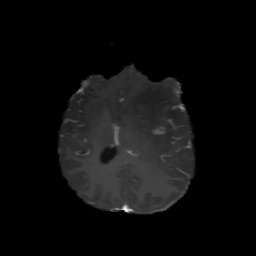

In [ ]:
from IPython.display import Image, display
from pathlib import Path

# --- 6.1 แสดงรายละเอียดการตรวจจับ ---
CLASS_NAMES = {0: "negative", 1: "positive"}
if prediction_results and len(prediction_results[0].boxes):
    print("🔍 รายละเอียดการตรวจจับ:")
    for i, box in enumerate(prediction_results[0].boxes):
        cls_id = int(box.cls)
        conf = float(box.conf)
        coords = box.xyxy[0].tolist()
        print(f"  [{i+1}] Class: {CLASS_NAMES.get(cls_id, cls_id)} | Confidence: {conf:.2%} | Box: [{coords[0]:.0f}, {coords[1]:.0f}, {coords[2]:.0f}, {coords[3]:.0f}]")
else:
    print("⚠️ ไม่พบวัตถุที่ตรวจจับได้ - ลองเพิ่ม epochs หรือตรวจสอบ dataset")

# --- 6.2 แสดงภาพผลการ predict ---
predict_base = PROJECT_DIR / "predict"
predict_dirs = sorted(predict_base.glob("predict*")) if predict_base.exists() else []

if predict_dirs:
    latest_dir = predict_dirs[-1]
    images = sorted(latest_dir.glob("*.jpg"))
    for img_path in images:
        print(f"\n📷 ภาพผลการตรวจจับ: {img_path.name}")
        display(Image(filename=str(img_path), width=600))
else:
    print("⚠️ ยังไม่ได้รัน Predict - กรุณารัน Part 4 ก่อน")

# --- 6.3 แสดงรายการไฟล์ ---
print(f"\n📂 ไฟล์ทั้งหมดใน Project Directory:")
for f in sorted(PROJECT_DIR.iterdir()):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  📄 {f.name} ({size_mb:.1f} MB)")
    else:
        print(f"  📁 {f.name}/")

---
## 📝 สรุป (Summary)

| หัวข้อ | รายละเอียด |
|--------|-----------|
| **โมเดล** | YOLO11n (เสถียร, เบา) |
| **Task** | Object Detection - ตรวจจับเนื้องอกสมอง |
| **Dataset** | brain-tumor (893 train / 223 val) |
| **Pipeline** | Train → Predict → Export → Display |
| **Project Dir** | `/content/drive/MyDrive/YOLO_Labs/brain_tumor/` |

### 🧪 ลองทำเพิ่มเติม:
1. เพิ่ม `EPOCHS` เป็น 100 แล้วเปรียบเทียบ mAP
2. ลองใช้โมเดล `yolo11s.pt` แทน `yolo11n.pt`
3. เปลี่ยน `EXPORT_FORMAT` เป็น `tflite` สำหรับ mobile

### Citation
```bibtex
@dataset{Jocher_Ultralytics_Datasets_2024,
    author = {Jocher, Glenn and Rizwan, Muhammad},
    title = {Ultralytics Datasets: Brain-tumor Detection Dataset},
    url = {https://docs.ultralytics.com/datasets/detect/brain-tumor/},
    year = {2024}
}
```

---
Crafted with 💙 by [Ultralytics](https://ultralytics.com/)